## **Предобработка данных**

In [71]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import warnings


Загрузим данные:

In [56]:
df = pd.read_csv('~/projects/ml_stage_classifier/data/data.csv', sep=';', skip_blank_lines=True)

In [57]:
df

,id,Стадия,Возраст,Способность пациента к ходьбе и бегу,Баллы мускулатуры (верхние конечности),Баллы мускулатуры (нижние конечности),Применение миопатических приемов Говерса при вставании с пола (использование перекаты),Применение миопатических приемов Говерса при вставании с пола (использование опоры),Тест с шестиминутной ходьбой,Приседания,...,Сколиоз (стадии сколиоза по его выраженности),Сколиоз (спутники сколиотической деформации),Кардиомиопатия,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27
0,1.0,6,11.0,Не ходит,3,2,NaN,NaN,NaN,NaN,...,Сколиотическая деформация,NaN,Синусовая тахикардия,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,6,14.0,Не ходит,3,2,NaN,NaN,NaN,NaN,...,NaN,NaN,Синусовая тахикардия,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,3 или 4 [2 или 3],7.0,"Бегает с отрывом двух ног от земли, но без фаз...",4,4,Подъем с пола с переворотом на живот,Подъем с пола с опорой на две руки о пол и бед...,от 350 м до 500 м,Приседает только с использованием приемов Гове...,...,Формирующийся сколиоз,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,6,11.0,Не ходит,3,2,NaN,NaN,NaN,NaN,...,Сколиотическая деформация,Деформация грудной клетки,"Синусовая тахикардия, Дилатационная кардиомиоп...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,6,12.0,Не ходит,2-3,1-2,NaN,NaN,NaN,NaN,...,Сколиотическая деформация,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
790,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
791,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Удалим пустые строки и столбцы:

In [58]:
df = df.dropna(axis=0, how='all')
df = df.dropna(axis=1, how='all')

In [59]:
df.shape

(136, 21)

Далее будем работать с каждым признаком постепенно и обрабатывать его:

### **1. Стадия (таргет)**

In [60]:
df['Стадия']

0                      6
1                      6
2      3 или 4 [2 или 3]
3                      6
4                      6
             ...        
131                    2
132                    2
133                    3
134                    4
135                5 [6]
Name: Стадия, Length: 136, dtype: str

In [73]:
df['Стадия'].isna().sum()

np.int64(0)

In [61]:
df['Стадия'].value_counts()

Стадия
6                    38
3                    30
2                    14
4                    11
7                    10
1 [2]                 7
6 [5]                 5
1                     5
5                     5
5 [4]                 3
2 или 3               2
1 [2 или 3]           2
5 [6]                 2
3 или 4 [2 или 3]     1
2 [1]                 1
Name: count, dtype: int64

На данный момент значения представляют собой строковые данные, при этом есть пограничные ситуации, когда точную стадию определить нельзя. Примем упрощения и будем обрабатывать признак следующим образом:

- если при пограничном случае есть значения в $[]$, то берем первое из них

- если скобок нет, например "2 или 3", то берем первое значение

In [63]:
def extraxt_stage_priority(val):
    if pd.isna(val):
        return np.nan
    
    s = str(val)

    #
    match_bracket = re.search(r'\[(\d+)', s)

    if match_bracket:
        return int(match_bracket.group(1))
    
    # 
    match_first = re.search(r'(\d+)', s)
    if match_first:
        return int(match_first.group(1))
    
    return np.nan

In [64]:
df['Стадия'] = df['Стадия'].apply(extraxt_stage_priority)

In [65]:
df['Стадия'].value_counts()

Стадия
6    40
3    30
2    26
4    14
5    10
7    10
1     6
Name: count, dtype: int64

In [66]:
df['Стадия'].dtype

dtype('int64')

(array([ 6., 26., 30., 14., 10., 40., 10.]),
 array([1.        , 1.85714286, 2.71428571, 3.57142857, 4.42857143,
        5.28571429, 6.14285714, 7.        ]),
 <BarContainer object of 7 artists>)

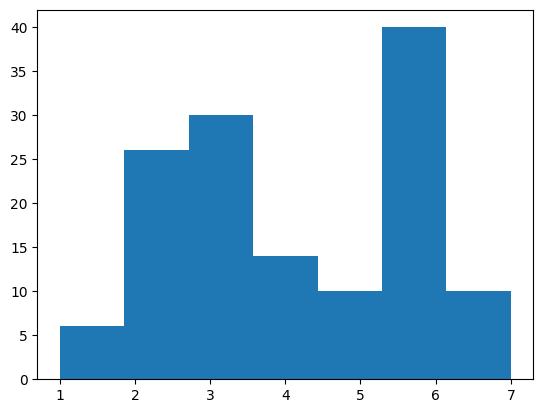

In [75]:
plt.hist(x=df['Стадия'], bins=7)

Как видим таргет корректно обработан, и может быть использован в моделе.

### **2. Возраст**

In [67]:
df['Возраст']

0      11.0
1      14.0
2       7.0
3      11.0
4      12.0
       ... 
131     7.0
132     6.0
133     8.0
134    10.0
135    11.0
Name: Возраст, Length: 136, dtype: float64

In [68]:
df['Возраст'].value_counts()

Возраст
7.0     14
6.0     14
8.0     12
9.0     12
11.0    11
14.0    11
12.0     9
13.0     9
4.0      8
5.0      8
10.0     8
3.0      6
17.0     4
16.0     4
15.0     3
2.0      3
Name: count, dtype: int64

In [69]:
df['Возраст'].dtype

dtype('float64')

In [70]:
df['Возраст'].isna().sum()

np.int64(0)

С возрастом все в порядке, пропусков нет, данные в численном виде. Можем идти дальше.

### **3. Способность пациента к ходьбе и бегу**

In [ ]:
mobility = 'Способность пациента к ходьбе и бегу'
df[mobility].value_counts()

Способность пациента к ходьбе и бегу
Не ходит                                                                    48
Способность к бегу по типу "Duchenne jog" (напоминает спортивную ходьбу)    29
Бегает с отрывом двух ног от земли, но без фазы полета                      24
Невозможность бега при сохранении ходьбы                                    20
Невозможность самостоятельно пройти 10 м                                     8
Бегает с отрывом двух ног от земли, присутствует фаза полета                 6
Name: count, dtype: int64

In [ ]:
df[mobility].isna().sum()

np.int64(1)

Согласно справочнику, значения имеют четкий порядок ухудшения. Закодируем их числами от 1 до 6:

In [78]:
mobility_map = {
    'Бегает с отрывом двух ног от земли, присутствует фаза полета': 1,
    'Бегает с отрывом двух ног от земли, но без фазы полета': 2,
    'Способность к бегу по типу "Duchenne jog" (напоминает спортивную ходьбу)': 3,
    'Невозможность бега при сохранении ходьбы': 4,
    'Невозможность самостоятельно пройти 10 м': 5,
    'Не ходит': 6
}

Обрабатываем данные и пропуски, заполнив их медианой:

In [ ]:
df[mobility] = df[mobility].map(mobility_map)

In [ ]:
mobility_mode = df[mobility].mode()[0]
df[mobility] = df[mobility].fillna(mobility_mode)

Заметим, что в случае значений `Не ходит` и `Невозможность самостоятельно пройти 10 м'`,  то в таком случае в последующих признаках связанные с работой ног пациент имеет пропуски, поэтому имеет смысл проставить заполнить их худшими значениями. 

In [120]:
def impute_functional_tests(row):
    mobility = row['Способность пациента к ходьбе и бегу']
    
    # Если пациент не ходит (6) или не может пройти 10 м (5) — ставим худшие значения
    if mobility >= 5:
        return {
            'Тест с шестиминутной ходьбой': 0,  # 0 метров
            'Ходьба по лестнице (подъем)': 5,    # "Невозможность"
            'Ходьба по лестнице (спуск)': 5,
            'Подпрыгивания (вверх на 2-х ногах)': 5,
            'Подпрыгивания (вверх на 1-ой ноге)': 5,
            'Приседание': 5,
        }
    # Если мобильность = 4 (не может бегать, но ходит) — тоже ограничения
    elif mobility == 4:
        return {
            'Подпрыгивания (вверх на 2-х ногах)': 4,  # "Переминается"
            'Подпрыгивания (вверх на 1-ой ноге)': 4,
        }
    return {}

In [121]:
cols_to_impute = [
    'Тест с шестиминутной ходьбой',
    'Ходьба по лестнице (подъем)',
    'Ходьба по лестнице (спуск)',
    'Подпрыгивания (вверх на 2-х ногах)',
    'Подпрыгивания (вверх на 1-ой ноге)',
    'Приседания',
]

# 1. Снимаем строгую типизацию pandas (разрешаем mixed types)
for col in cols_to_impute:
    if col in df.columns:
        df[col] = df[col].astype(object)

# 2. Применяем импутацию
for idx, row in df.iterrows():
    imputes = impute_functional_tests(row)
    for col, val in imputes.items():
        if col in df.columns and pd.isna(row[col]):
            df.loc[idx, col] = val

### **4. Баллы мускулатуры**

In [96]:
cols_muscle = ['Баллы мускулатуры (верхние конечности)', 'Баллы мускулатуры (нижние конечности)']

In [97]:
df[cols_muscle].value_counts()

Баллы мускулатуры (верхние конечности)  Баллы мускулатуры (нижние конечности)
4                                       4                                        13
3-4                                     3-4                                      12
3                                       3                                        10
                                        2                                         8
4                                       3                                         7
2-3                                     2-3                                       5
2                                       2                                         3
3                                       2-3                                       3
1-2                                     0-1                                       3
                                        1                                         3
3,5                                     3                                         

In [98]:
df[cols_muscle].isna().sum()

Баллы мускулатуры (верхние конечности)    16
Баллы мускулатуры (нижние конечности)     38
dtype: int64

Преобразуем диапазоны (например, "2-3" или "3,5-4") в среднее числовое значение.

In [ ]:
def parse_muscle_score(val):
    """
    Преобразует '2-3' -> 2.5, '3,5-4' -> 3.75, '4' -> 4.0
    """
    if pd.isna(val):
        return np.nan
    
    s = str(val).strip().replace(',', '.')
    if '-' in s:
        try:
            parts = s.split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return np.nan
    else:
        try:
            return float(s)
        except ValueError:
            return np.nan

In [99]:
for col in cols_muscle:
    df[col] = df[col].apply(parse_muscle_score)
    median_val = df[col].median() # пропуски заполняем медианой
    df[col] = df[col].fillna(median_val)

In [100]:
df[cols_muscle].isna().sum()

Баллы мускулатуры (верхние конечности)    0
Баллы мускулатуры (нижние конечности)     0
dtype: int64

### **5. Приемы Говерса**

In [105]:
cols_gowers = [
    'Применение миопатических приемов Говерса при вставании с пола (использование опоры)',
    'Применение миопатических приемов Говерса при вставании с пола (использование перекаты)'
]

In [ ]:
df[cols_gowers].value_counts()

Применение миопатических приемов Говерса при вставании с пола (использование опоры)  Применение миопатических приемов Говерса при вставании с пола (использование перекаты)
Подъем с пола с опорой на две руки о пол и бедра, "взбираясь по себе"                Подъем с пола с переворотом на живот                                                      22
Подъем с пола с опорой на одну руку о пол или о бедро                                Подъем с пола с перекатом                                                                 17
Подъем с пола с использованием окружающей мебели при вставании                       Подъем с пола с переворотом на живот                                                       4
Подъем с пола с опорой на одну руку о пол или о бедро                                Подъем с пола с переворотом на живот                                                       2
Подъем с пола с опорой на две руки о пол и бедра, "взбираясь по себе"                Подъем с пола с перекатом      

In [ ]:
df[cols_gowers].isna().sum()

Применение миопатических приемов Говерса при вставании с пола (использование опоры)       63
Применение миопатических приемов Говерса при вставании с пола (использование перекаты)    83
dtype: int64

Закодируем текстовые описания в числа (Ordinal Encoding) от 1 (легко) до 5 (невозможно), основываясь на справочнике v290425.

In [104]:
# А. Использование перекатов
map_rolls = {
    'Подъем с пола без переката': 1,
    'Подъем с пола с перекатом': 2,
    'Подъем с пола с переворотом на живот': 3,
    # Если есть пустые значения, мы заполним их позже, но маппинг готов
}

# Б. Использование опоры
map_support = {
    'Подъем с пола без опоры': 1,
    'Подъем с пола с опорой на одну руку о пол или о бедро': 2,
    'Подъем с пола с опорой на одну руку о пол': 2, # Вариант написания
    'Подъем с пола с опорой на две руки о пол и бедра, "взбираясь по себе"': 3,
    'Подъем с пола с опорой на две руки о пол и бёдра, "взбираясь по себе"': 3, # Ё/Е
    'Подъем с пола с использованием окружающей мебели при вставании': 4,
    'Утрата навыка подъема на ноги': 5
}

In [106]:
df[cols_gowers[1]] = df[cols_gowers[1]].map(map_rolls)
df[cols_gowers[0]] = df[cols_gowers[0]].map(map_support)

Заполняем пропуски медианой:

In [108]:
for col in cols_gowers:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)